# A05 — Targeted Interventions & Qualitative Routing Cases
Covers Appendix J — targeted semantic interventions and behavioral routing cases:
- Figure J1(a): Score drop by cue-family perturbation type
- Figure J1(b): Routing profile heatmaps for each behavioral case
- Table J1: Routing mass by family and stage for each behavioral case


In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import appendix_viz_helpers as viz
importlib.reload(viz)

apply_style    = viz.apply_style
load_csv       = viz.load_csv
annotate_demo  = viz.annotate_demo
clean_axes     = viz.clean_axes
dataset_label  = viz.dataset_label
metric_limits  = viz.metric_limits
panel_label    = viz.panel_label
PALETTE        = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
apply_style()


In [2]:
# appendix_intervention_summary.csv  cols: dataset, intervention, intervention_label, target_family, test_mrr20, test_seen_mrr20
# appendix_case_routing_profile.csv   cols: dataset, group, stage_name, routed_family, usage_share
interv_df = load_csv('appendix_intervention_summary.csv')
cases_df  = load_csv('appendix_case_routing_profile.csv')
interv_df['dataset_label'] = interv_df['dataset'].map(dataset_label)
cases_df['dataset_label']  = cases_df['dataset'].map(dataset_label)

# Compute score drop relative to the 'full' (unperturbed) baseline per dataset
full_scores = (
    interv_df[interv_df['intervention'] == 'full']
    .groupby('dataset')['test_seen_mrr20'].mean()
)
interv_df['score_drop'] = interv_df.apply(
    lambda r: full_scores.get(r['dataset'], np.nan) - r['test_seen_mrr20'], axis=1
)
print(f"interv_df: {interv_df.shape}  interventions: {interv_df['intervention'].unique()}")
print(f"cases_df:  {cases_df.shape}   groups: {cases_df['group'].unique()}")


interv_df: (32, 10)  interventions: ['full' 'feature_zero_all' 'zero_tempo' 'zero_focus' 'zero_memory'
 'zero_exposure' 'shuffle_tempo' 'shuffle_focus']
cases_df:  (96, 8)   groups: ['memory_plus' 'focus_plus' 'tempo_plus' 'exploration_plus']


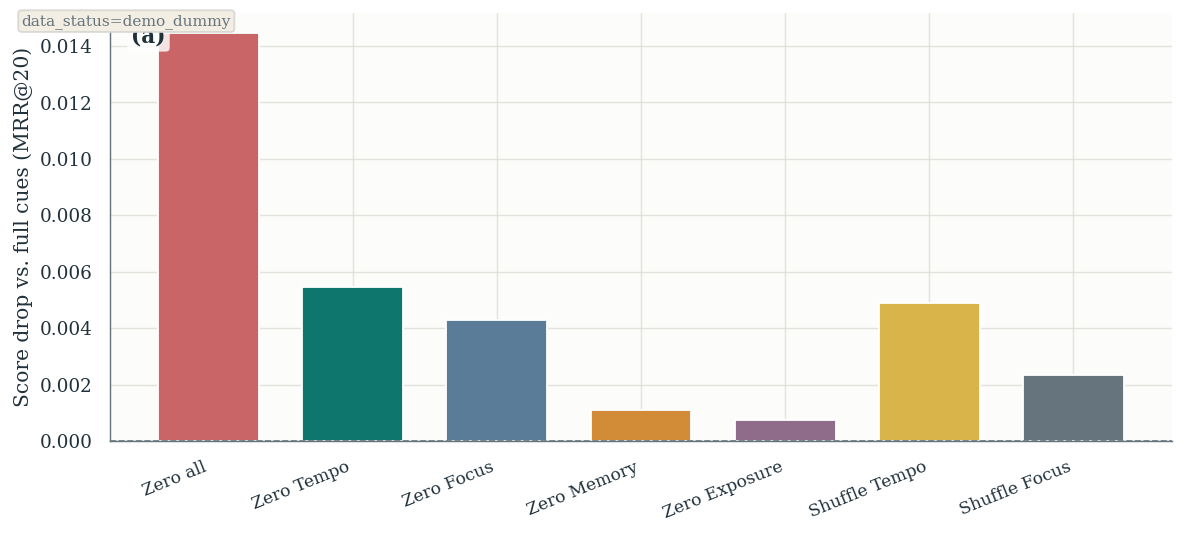

In [3]:
# ── Figure J1(a) — Score drop by cue-family perturbation ─────────────────────────
# Shows how much MRR@20 drops when each cue family (target_family) is zeroed or shuffled.
# 'full' is the baseline (drop=0); other interventions show magnitude of impact.
FAMILY_ORDER  = ['all', 'tempo', 'focus', 'memory', 'exposure']
FAMILY_LABELS = {'all': 'All cues', 'tempo': 'Tempo', 'focus': 'Focus',
                 'memory': 'Memory', 'exposure': 'Exposure'}
INV_ORDER = ['feature_zero_all', 'zero_tempo', 'zero_focus', 'zero_memory', 'zero_exposure',
             'shuffle_tempo',    'shuffle_focus']
INV_LABELS = {
    'feature_zero_all': 'Zero all',
    'zero_tempo':       'Zero Tempo',
    'zero_focus':       'Zero Focus',
    'zero_memory':      'Zero Memory',
    'zero_exposure':    'Zero Exposure',
    'shuffle_tempo':    'Shuffle Tempo',
    'shuffle_focus':    'Shuffle Focus',
}
PAL_LIST = [PALETTE['rose'], PALETTE['route'], PALETTE['blue'],
            PALETTE['orange'], PALETTE['plum'], PALETTE['gold'], PALETTE['muted']]

sub = interv_df[interv_df['intervention'] != 'full'].copy()
present_inv = [i for i in INV_ORDER if i in sub['intervention'].unique()]

fig, ax = plt.subplots(figsize=(9.0, 4.0), constrained_layout=True)
x     = np.arange(len(present_inv))
width = 0.7
drops = [sub[sub['intervention'] == inv]['score_drop'].mean() for inv in present_inv]
cols  = PAL_LIST[:len(present_inv)]
ax.bar(x, drops, width, color=cols)
ax.set_xticks(x)
ax.set_xticklabels([INV_LABELS.get(inv, inv) for inv in present_inv], rotation=22, ha='right', fontsize=9.5)
ax.set_ylabel('Score drop vs. full cues (MRR@20)')
ax.axhline(0, color=PALETTE['muted'], linewidth=0.9, linestyle='--')
clean_axes(ax)
panel_label(ax, 'a')
annotate_demo(fig, interv_df)
plt.show()


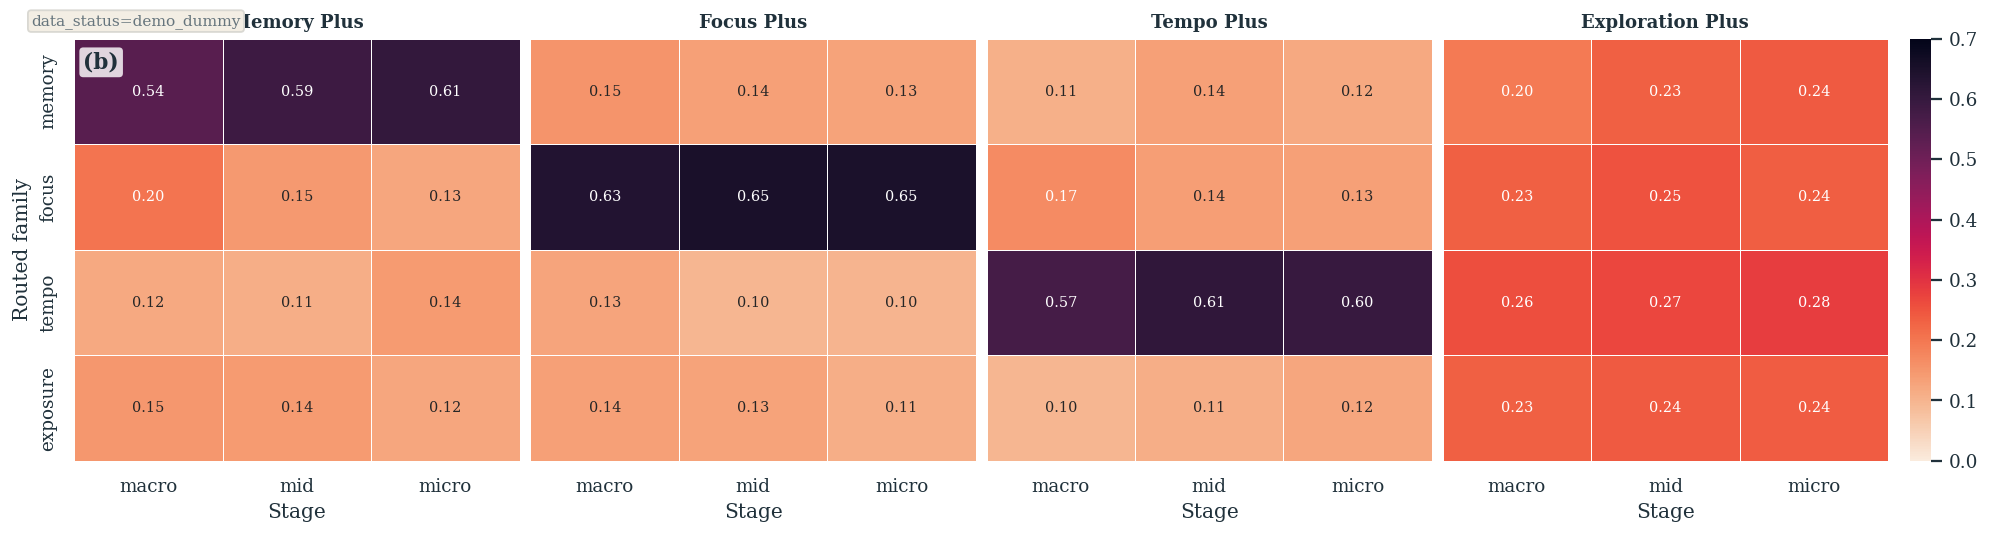

In [ ]:
# ── Figure J1(a) — Score drop vs full cues by perturbation type ──────────────────
INV_ORDER = ['feature_zero_all', 'zero_tempo', 'zero_focus', 'zero_memory', 'zero_exposure',
             'shuffle_tempo', 'shuffle_focus']
INV_LABELS = {
    'feature_zero_all': 'Zero all',
    'zero_tempo':       'Zero Tempo',
    'zero_focus':       'Zero Focus',
    'zero_memory':      'Zero Memory',
    'zero_exposure':    'Zero Exposure',
    'shuffle_tempo':    'Shuffle Tempo',
    'shuffle_focus':    'Shuffle Focus',
}
PAL_LIST = [PALETTE['rose'], PALETTE['route'], PALETTE['blue'],
            PALETTE['orange'], PALETTE['plum'], PALETTE['gold'], PALETTE['muted']]

sub = interv_df[interv_df['intervention'] != 'full'].copy()
present_inv = [i for i in INV_ORDER if i in sub['intervention'].unique()]
drops  = [sub[sub['intervention'] == inv]['score_drop'].mean() for inv in present_inv]
labels = [INV_LABELS.get(i, i) for i in present_inv]
colors = PAL_LIST[:len(present_inv)]

fig, ax = plt.subplots(figsize=(8.0, 3.8), constrained_layout=True)
ax.bar(labels, drops, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(0, color=PALETTE['muted'], linewidth=0.9, linestyle='--')
ax.set_ylabel('Score drop vs. full cues (MRR@20)')
ax.tick_params(axis='x', rotation=20)
clean_axes(ax)
annotate_demo(fig, interv_df)
plt.show()


In [ ]:
# ── Figure J1(b) — Stage-wise routing profile per behavioral case group ──────────
CASE_GROUPS = ['memory_plus', 'focus_plus', 'tempo_plus', 'exploration_plus']
STAGE_ORDER = ['macro', 'mid', 'micro']
ROUTED_FAMS = ['memory', 'focus', 'tempo', 'exposure']

fig, axes = plt.subplots(1, len(CASE_GROUPS), figsize=(3.6 * len(CASE_GROUPS), 3.8),
                          constrained_layout=True, sharey=True)
for ax, grp in zip(axes, CASE_GROUPS):
    sub = cases_df[cases_df['group'] == grp]
    hm = (
        sub.groupby(['routed_family', 'stage_name'])['usage_share'].mean()
        .unstack('stage_name')
        .reindex(index=ROUTED_FAMS, columns=STAGE_ORDER)
        .fillna(0)
    )
    sns.heatmap(hm, ax=ax, cmap='rocket_r', vmin=0, vmax=0.7, linewidths=0.5,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                cbar=(ax is axes[-1]))
    ax.set_title(grp.replace('_plus', '').title(), fontsize=10)
    ax.set_xlabel('Stage')
    ax.set_ylabel('Routed family' if ax is axes[0] else '')

annotate_demo(fig, cases_df)
plt.show()


stage_name,macro,mid,micro
group,,,
memory_plus,memory,memory,memory
focus_plus,focus,focus,focus
tempo_plus,tempo,tempo,tempo
exploration_plus,tempo,tempo,tempo
